In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data set/cs-training.csv")

In [3]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [8]:
df.rename(columns={
    "Unnamed: 0": "customer_id",
    "SeriousDlqin2yrs": "default",
    "RevolvingUtilizationOfUnsecuredLines": "credit_utilization",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "late_30_59_days",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "open_credit_lines",
    "NumberOfTimes90DaysLate": "late_90_days",
    "NumberRealEstateLoansOrLines": "real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "late_60_89_days",
    "NumberOfDependents": "dependents"
}, inplace=True)

In [53]:
print(df['default'].value_counts())
print(df['default'].value_counts(normalize=True)*100)

default
0    139974
1     10026
Name: count, dtype: int64
default
0    93.316
1     6.684
Name: proportion, dtype: float64


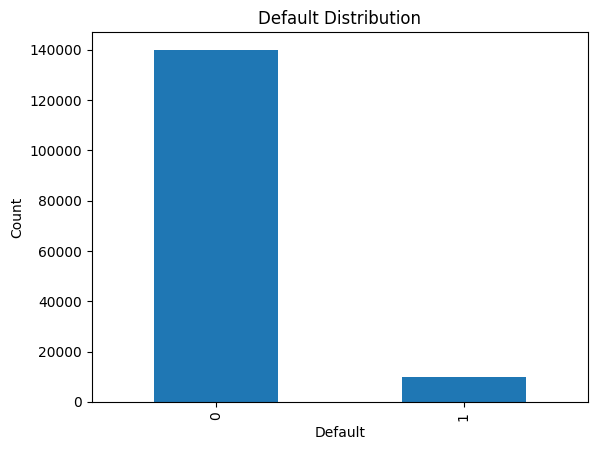

In [11]:
df["default"].value_counts().plot(kind="bar")

plt.title("Default Distribution")
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()

Because credit datasets are often imbalanced) In our dataset, only 6)7% of customers defaulted) A model predicting everyone as non-default would achieve over 93% accuracy while failing to identify risky customers) Therefore, metrics such as Precision, Recall, F1-score, and ROC-AUC are more appropriate)

In [13]:
df.describe()

,customer_id,default,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,open_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [14]:
df.select_dtypes(include=['int64', "float64"]).columns

Index(['customer_id', 'default', 'credit_utilization', 'age',
       'late_30_59_days', 'debt_ratio', 'monthly_income', 'open_credit_lines',
       'late_90_days', 'real_estate_loans', 'late_60_89_days', 'dependents'],
      dtype='str')

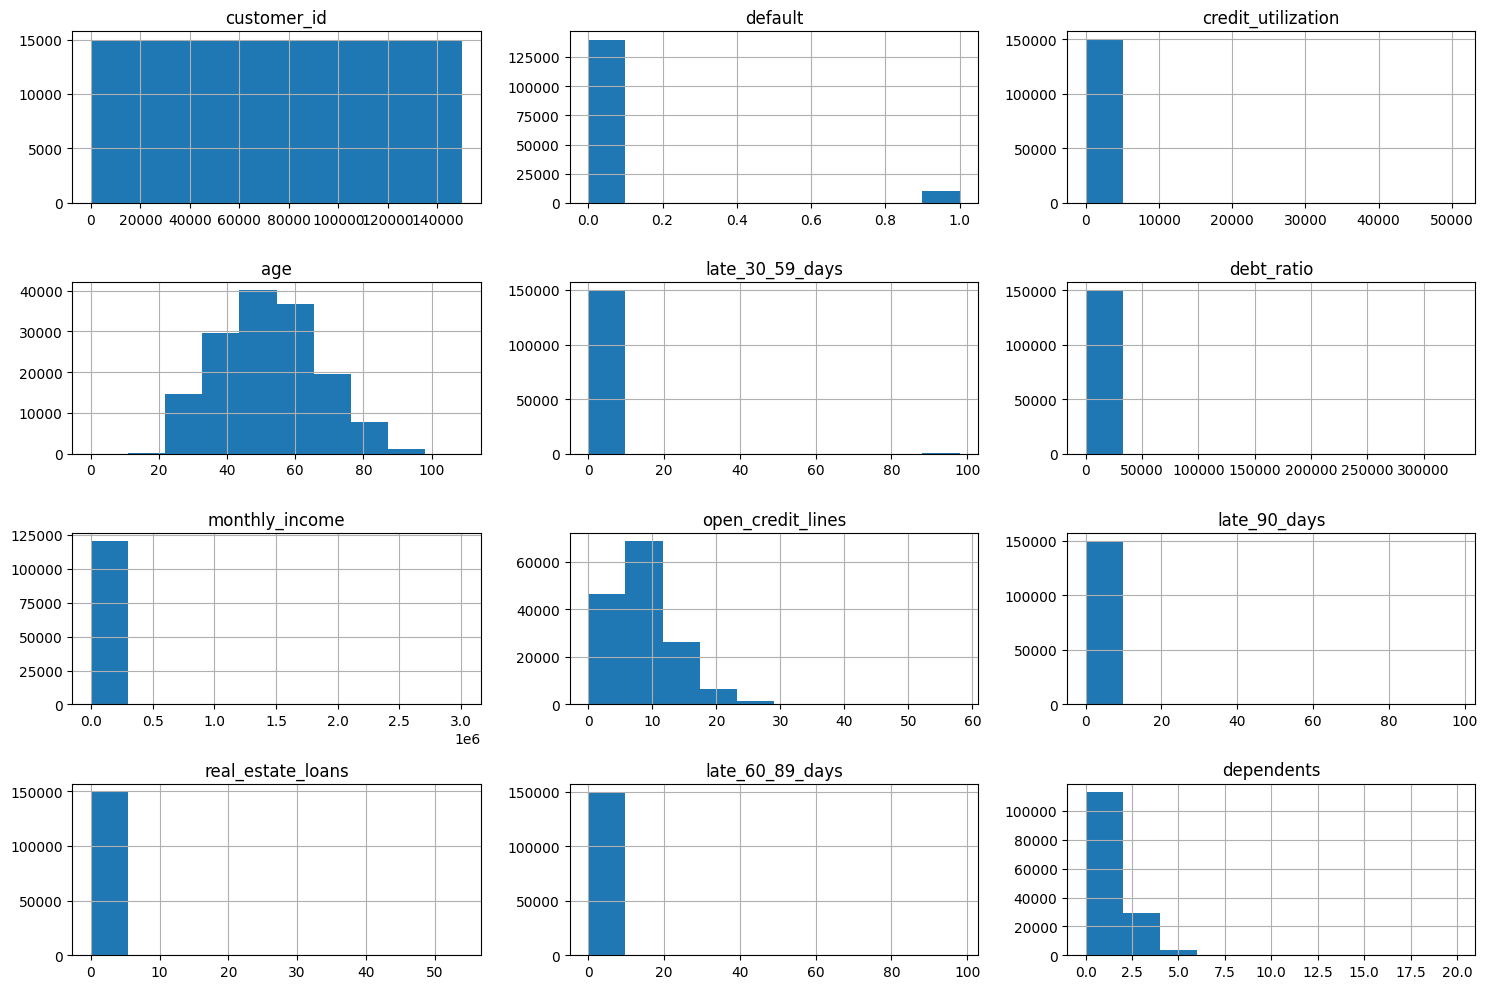

In [15]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [16]:
df.groupby("default").mean()

,customer_id,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,open_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
default,,,,,,,,,,,
0,74968.042429,6.168855,52.751375,0.280109,357.151168,6747.837774,8.493620,0.135225,1.020368,0.126666,0.743417
1,75453.643427,4.367282,45.926591,2.388490,295.121066,5630.826493,7.882306,2.091362,0.988530,1.828047,0.948208


1)The dataset is highly imbalanced, with only 6.68% of customers experiencing default

2) Defaulters tend to be younger than non-defaulters

3) Historical late payments show the strongest relationship with default behavior

4) Defaulters generally report lower monthly income

5) Several numerical variables exhibit heavy skewness and extreme outliers

# Correlation Heatmap

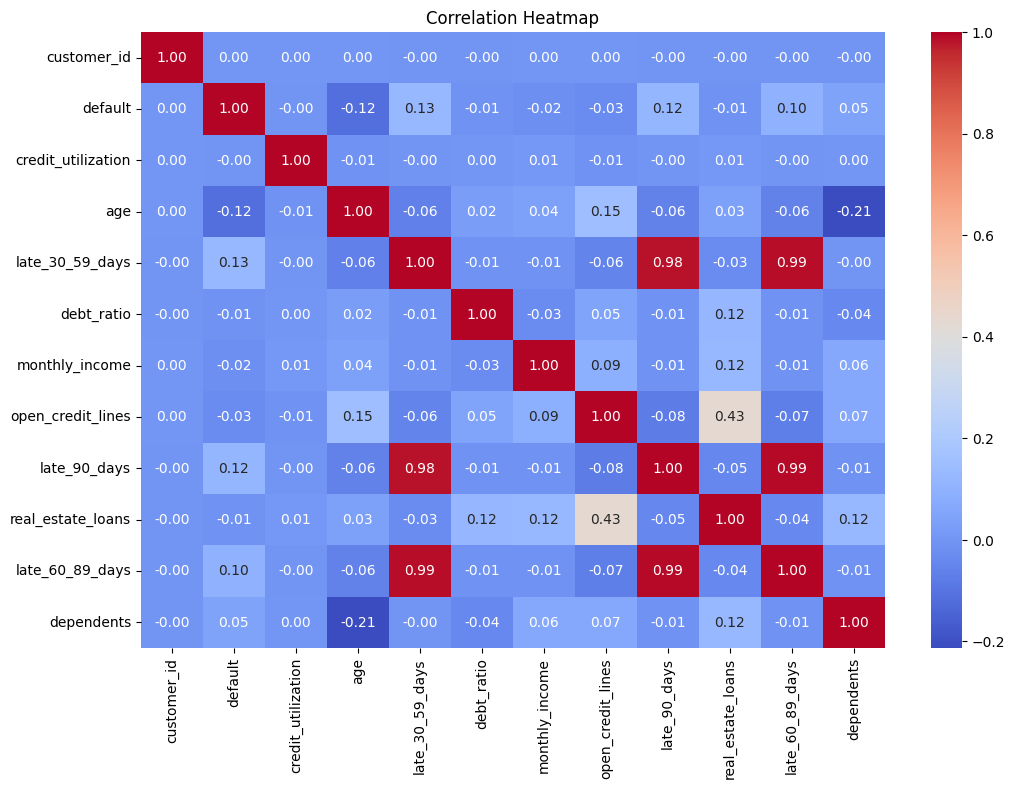

In [17]:
# Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

The delinquency variables showed extremely high correlation, suggesting they capture similar behavioral patterns) This indicates possible multicollinearity, and feature engineering could combine them into a single delinquency indicator)

# Boxplots by Default

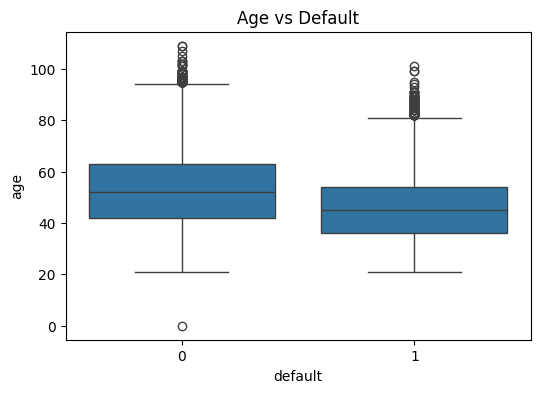

In [18]:
# Boxplot for Age
plt.figure(figsize=(6,4))

sns.boxplot(x="default", y="age", data=df)

plt.title("Age vs Default")
plt.show()

Age contributes some signal but is insufficient independently

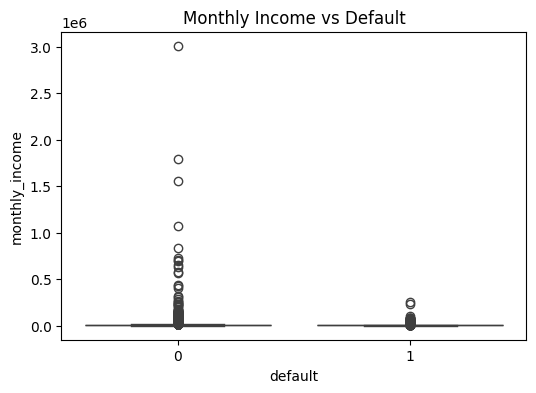

In [19]:
# Boxplot for Monthly Income
plt.figure(figsize=(6,4))

sns.boxplot(x="default", y="monthly_income", data=df)

plt.title("Monthly Income vs Default")
plt.show()

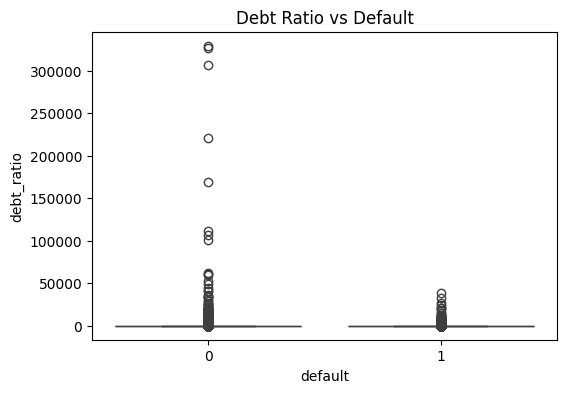

In [20]:
# Boxplot for Debt Ratio
plt.figure(figsize=(6,4))

sns.boxplot(x="default", y="debt_ratio", data=df)

plt.title("Debt Ratio vs Default")
plt.show()

# Missing Value Visualization

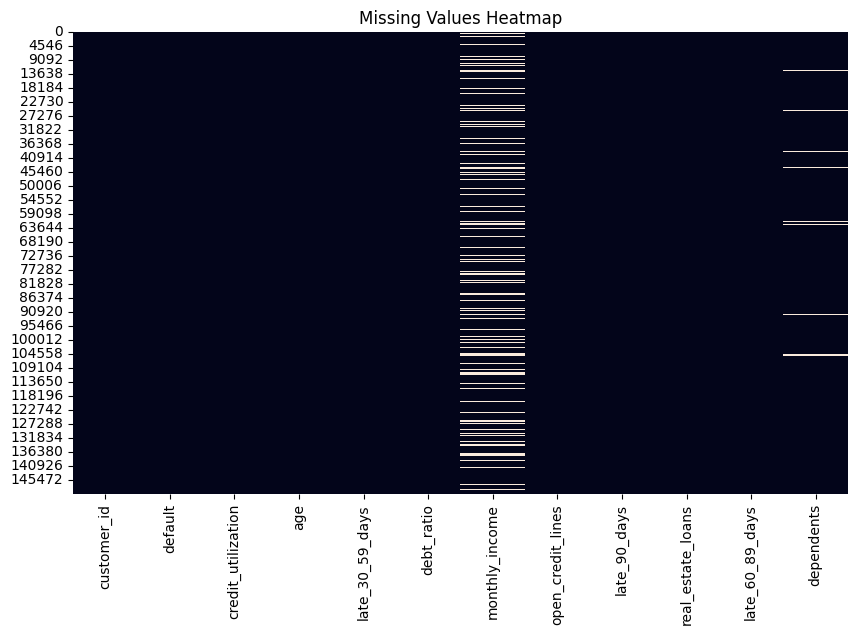

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

1) The dataset is highly imbalanced, with only 6)68% of borrowers defaulting)
2) Borrowers who default tend to be younger)
3) Historical delinquency is the strongest behavioral indicator of future default)
4) Monthly income and debt ratio contain substantial outliers and skewness)
5) Missing values are concentrated in monthly income and dependents, requiring imputation strategies)
6) Delinquency-related features exhibit strong multicollinearity and may benefit from feature engineering)

# Phase 2: Data Cleaning and Preprocessing

Goal:
Prepare the dataset for machine learning while avoiding common mistakes such as data leakage.

Steps:
1. Separate features and target.
2. Split data into training and testing sets.
3. Handle missing values.
4. Address outliers.
5. Prepare data for modeling.

In [22]:
# Separate features and target

X = df.drop(columns=["default", "customer_id"])
y = df["default"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used for prediction:")
print(X.columns.tolist())

Feature matrix shape: (150000, 10)
Target shape: (150000,)

Features used for prediction:
['credit_utilization', 'age', 'late_30_59_days', 'debt_ratio', 'monthly_income', 'open_credit_lines', 'late_90_days', 'real_estate_loans', 'late_60_89_days', 'dependents']


1. Features (X): These are the inputs the model will use to make decisions.
2. Target (y): This is the answer we want the model to learn.

## Data leakage
Data leakage occurs when information that would not be available at prediction time unintentionally influences the training process, leading to overly optimistic performance estimates.

## Train-Test Split

The dataset is highly imbalanced (93.3% non-default vs 6.7% default).

Therefore, stratified sampling is used to preserve the class distribution in both training and testing datasets.

Split used:
- Training: 80%
- Testing: 20%
- Stratification based on the target variable (`default`)
- Random state: 42 for reproducibility

In [23]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, # Use 20% of the data as the final exam
    stratify=y, # Maintain the 93:7 ratio in both sets.
    random_state=42 # Shuffle the same way every time.
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training feature shape: (120000, 10)
Testing feature shape: (30000, 10)

Training target distribution:
default
0    93.315833
1     6.684167
Name: proportion, dtype: float64

Testing target distribution:
default
0    93.316667
1     6.683333
Name: proportion, dtype: float64


## Missing Value Strategy

Rows containing missing values were not dropped because a significant portion of the dataset would be lost.

Imputation strategy:
- Monthly Income → Median Imputation
- Dependents → Median Imputation

Median was preferred over mean because both variables exhibited skewed distributions and outliers during EDA.

In [24]:
# Missing values in training data

print("Missing values in X_train:\n")
print(X_train.isnull().sum())

print("\nPercentage missing:\n")
print((X_train.isnull().sum() / len(X_train) * 100).round(2))

Missing values in X_train:

credit_utilization        0
age                       0
late_30_59_days           0
debt_ratio                0
monthly_income        23675
open_credit_lines         0
late_90_days              0
real_estate_loans         0
late_60_89_days           0
dependents             3128
dtype: int64

Percentage missing:

credit_utilization     0.00
age                    0.00
late_30_59_days        0.00
debt_ratio             0.00
monthly_income        19.73
open_credit_lines      0.00
late_90_days           0.00
real_estate_loans      0.00
late_60_89_days        0.00
dependents             2.61
dtype: float64


In [25]:
income_median = X_train['monthly_income'].median()
dependents_median = X_train['dependents'].median()

print("monthly income median:", income_median)
print("monthly dependent median:", dependents_median)

monthly income median: 5390.0
monthly dependent median: 0.0


Learn from Training Data
->
Apply to Training Data
->
Apply the SAME values to Test Data

## Median Imputation

Missing values were imputed using statistics derived from the training set.

Training-set medians:
- Monthly Income: 5390.0
- Dependents: 0.0

The same values were applied to both training and testing datasets to avoid data leakage.

In [26]:
# fill in the values using the training medians

X_train["monthly_income"] = X_train["monthly_income"].fillna(income_median)
X_test["monthly_income"] = X_test["monthly_income"].fillna(income_median)

X_train["dependents"] = X_train["dependents"].fillna(dependents_median)
X_test["dependents"] = X_test["dependents"].fillna(dependents_median)

# verify

print("missing values X_train: \n")
print(X_train.isnull().sum())

print("missing values X_test: \n")
print(X_test.isnull().sum())

missing values X_train: 

credit_utilization    0
age                   0
late_30_59_days       0
debt_ratio            0
monthly_income        0
open_credit_lines     0
late_90_days          0
real_estate_loans     0
late_60_89_days       0
dependents            0
dtype: int64
missing values X_test: 

credit_utilization    0
age                   0
late_30_59_days       0
debt_ratio            0
monthly_income        0
open_credit_lines     0
late_90_days          0
real_estate_loans     0
late_60_89_days       0
dependents            0
dtype: int64


Split First
->
Learn preprocessing from X_train
->
Apply the same preprocessing to X_train
->
Apply the same preprocessing to X_test

## Feature Scaling for Logistic Regression

Logistic Regression is sensitive to the scale of input features.

StandardScaler was used to standardize the features by learning the mean and standard deviation from the training data only.

The same transformation was then applied to the test data to avoid data leakage.

In [27]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Learn scaling rules from X_train -> Immediately apply them to X_train
X_train_scaled = scaler.fit_transform(X_train)

# Do NOT learn anything new -> Use the SAME training rules -> Scale X_test
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\nType of X_train_scaled:", type(X_train_scaled))

Scaled training shape: (120000, 10)
Scaled testing shape: (30000, 10)

Type of X_train_scaled: <class 'numpy.ndarray'>


fit: Learn the rules from the training data.

For StandardScaler, it learns:

Mean of each feature
Standard deviation of each feature

transform: Apply the learned rules.

## Logistic Regression

Logistic Regression was used as the baseline classification model because it is simple, interpretable, and widely used in credit scoring applications.

The model predicts the probability of default and converts it into class labels using a decision threshold.

In [28]:
from sklearn.linear_model import LogisticRegression

# Create the model
log_reg = LogisticRegression(random_state=42)

# Train the model
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Predictions using Logistic Regression

Predictions were generated on the unseen test dataset to evaluate how well the model generalizes to new customers.

In [29]:
# Predict class labels

y_pred = log_reg.predict(X_test_scaled)

print("First 20 Predictions:")
print(y_pred[:20])

print("\nActual Values:")
print(y_test.iloc[:20].values)

First 20 Predictions:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]

Actual Values:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [30]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC-AUC
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("\nROC-AUC Score:", round(roc_auc, 4))

Accuracy: 0.934

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.58      0.04      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.52      0.52     30000
weighted avg       0.91      0.93      0.91     30000


Confusion Matrix:
[[27930    65]
 [ 1915    90]]

ROC-AUC Score: 0.7143


Logistic Regression achieved high overall accuracy (93.4%) due to the imbalanced nature of the dataset. However, it identified only 4% of actual defaulters, resulting in very low recall for the minority class. This indicates that despite appearing accurate, the model was ineffective at detecting risky borrowers. Therefore, additional strategies such as class balancing or alternative algorithms should be explored.

## balanced logistic regression

In [31]:
# made the balanced model
balanced_log_reg = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

# train the balanced model
balanced_log_reg.fit(X_train_scaled, y_train)

balanced_y_pred = balanced_log_reg.predict(X_test_scaled)

print("First 20 Predictions")
print(y_pred[:20])

print("actual values: ")
print(y_test.iloc[:20].values)



First 20 Predictions
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
actual values: 
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [32]:
# Accuracy
accuracy = accuracy_score(y_test, balanced_y_pred)
print("Accuracy:", round(accuracy, 4))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, balanced_y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, balanced_y_pred))

# ROC-AUC
balanced_y_prob = balanced_log_reg.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, balanced_y_prob)

print("\nROC-AUC Score:", round(roc_auc, 4))

Accuracy: 0.7762

Classification Report:


              precision    recall  f1-score   support

           0       0.97      0.78      0.87     27995
           1       0.18      0.67      0.29      2005

    accuracy                           0.78     30000
   macro avg       0.58      0.73      0.58     30000
weighted avg       0.92      0.78      0.83     30000


Confusion Matrix:
[[21944  6051]
 [  662  1343]]

ROC-AUC Score: 0.8021


## Logistic Regression vs Balanced Logistic Regression: Key Insights

The baseline Logistic Regression model achieved a high accuracy of 93.4%, which initially suggested strong performance. However, further evaluation revealed that the model identified only 4% of actual defaulters (Recall = 0.04). Due to the severe class imbalance in the dataset, the model predominantly predicted the majority class (non-default), making accuracy a misleading metric.

To address this issue, a Balanced Logistic Regression model was trained using `class_weight='balanced'`. This approach assigned greater importance to the minority class (defaulters), resulting in a substantial improvement in Recall from 4% to 67%. The model successfully identified 1,343 defaulters compared to only 90 identified by the baseline model.

Although the balanced model's overall accuracy decreased from 93.4% to 77.6%, this reduction was expected because the model became more aggressive in flagging risky customers, leading to an increase in false positives. Precision for defaulters decreased from 58% to 18%, indicating that a larger proportion of customers predicted as risky were actually safe borrowers.

Despite this trade-off, the balanced model achieved a significantly higher F1-score (0.29 vs 0.08) and improved ROC-AUC (0.8021 vs 0.7143), demonstrating a stronger ability to distinguish between defaulters and non-defaulters.

From a business perspective, the balanced model is more suitable for credit risk assessment because missing actual defaulters can result in substantial financial losses. Therefore, prioritizing Recall over Accuracy aligns more closely with the objective of identifying high-risk borrowers.


## Decision Tree Classifier

Decision Trees classify observations by recursively splitting the data into smaller groups using decision rules.

Unlike Logistic Regression, Decision Trees do not require feature scaling and can capture non-linear relationships between variables.

In [33]:
from sklearn.tree import DecisionTreeClassifier

# Create the model
dt = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


## Decision Tree Predictions

Predictions were generated on the unseen test dataset to evaluate the Decision Tree's ability to generalize to new borrowers.

In [34]:
# Decision Tree predictions

y_pred_dt = dt.predict(X_test)

print("First 20 Predictions:")
print(y_pred_dt[:20])

print("\nActual Values:")
print(y_test.iloc[:20].values)

First 20 Predictions:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]

Actual Values:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


Decision Trees may perform better because they can capture non-linear patterns and are robust to outliers. However, they may still struggle with class imbalance and could overfit the training data.

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Decision Tree probabilities
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt), 4))
print("Recall:", round(recall_score(y_test, y_pred_dt), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_dt), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_dt), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8983
Precision: 0.2556
Recall: 0.2728
F1 Score: 0.2639
ROC-AUC: 0.6089

Confusion Matrix:
[[26402  1593]
 [ 1458   547]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95     27995
           1       0.26      0.27      0.26      2005

    accuracy                           0.90     30000
   macro avg       0.60      0.61      0.60     30000
weighted avg       0.90      0.90      0.90     30000



A more complex model is not automatically a better model.

## Random Forest Classifier

Random Forest is an ensemble learning method that combines multiple Decision Trees and aggregates their predictions.

It reduces overfitting and often achieves better generalization compared to a single Decision Tree.

In [39]:
from sklearn.ensemble import RandomForestClassifier

# create the model
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

# train the model
rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Random Forest predictions
y_pred_rf = rf.predict(X_test)

# Random Forest probabilities
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9357
Precision: 0.5564
Recall: 0.1845
F1 Score: 0.2772
ROC-AUC: 0.8433

Confusion Matrix:
[[27700   295]
 [ 1635   370]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.56      0.18      0.28      2005

    accuracy                           0.94     30000
   macro avg       0.75      0.59      0.62     30000
weighted avg       0.92      0.94      0.92     30000



In [41]:
balanced_ft = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_estimators=100
)

# train the model
balanced_ft.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Random Forest predictions
balanced_y_pred_rf = balanced_ft.predict(X_test)

# Random Forest probabilities
balanced_y_prob_rf = balanced_ft.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, balanced_y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, balanced_y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, balanced_y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, balanced_y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, balanced_y_prob_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, balanced_y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, balanced_y_pred_rf))

Accuracy: 0.9243
Precision: 0.4234
Recall: 0.3651
F1 Score: 0.3921
ROC-AUC: 0.8456

Confusion Matrix:
[[26998   997]
 [ 1273   732]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     27995
           1       0.42      0.37      0.39      2005

    accuracy                           0.92     30000
   macro avg       0.69      0.66      0.68     30000
weighted avg       0.92      0.92      0.92     30000



In [44]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": balanced_ft.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

              Feature  Importance
0  credit_utilization    0.270819
3          debt_ratio    0.140072
1                 age    0.116148
4      monthly_income    0.115947
6        late_90_days    0.087702
2     late_30_59_days    0.083961
5   open_credit_lines    0.077775
8     late_60_89_days    0.043753
7   real_estate_loans    0.032023
9          dependents    0.031800


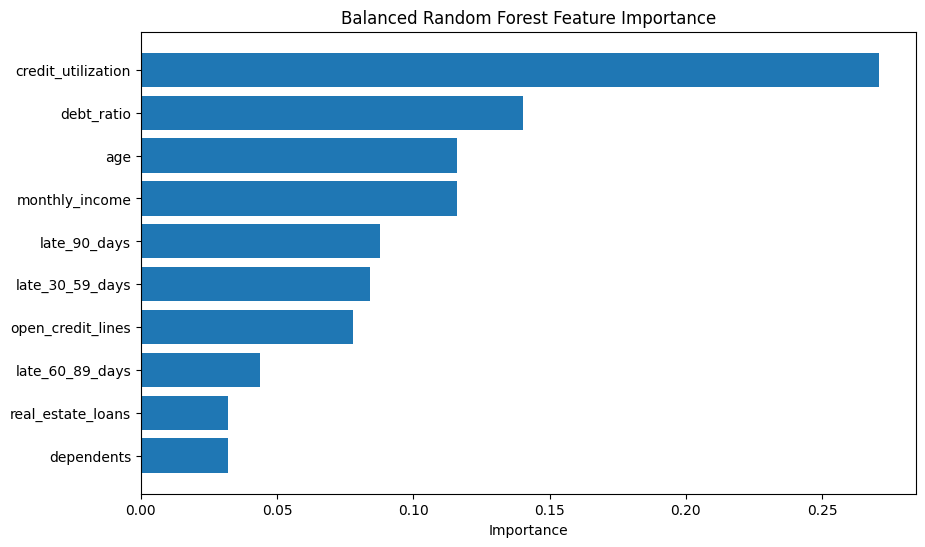

<Figure size 640x480 with 0 Axes>

In [49]:
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.xlabel("Importance")
plt.title("Balanced Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()
plt.savefig("../images/feature_importance.png")

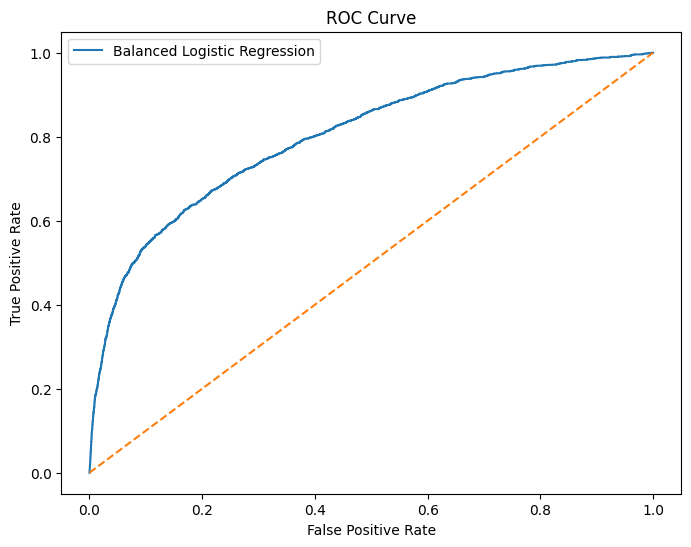

<Figure size 640x480 with 0 Axes>

In [51]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, balanced_y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr,
         label="Balanced Logistic Regression")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.savefig("../images/roc_curve.png")

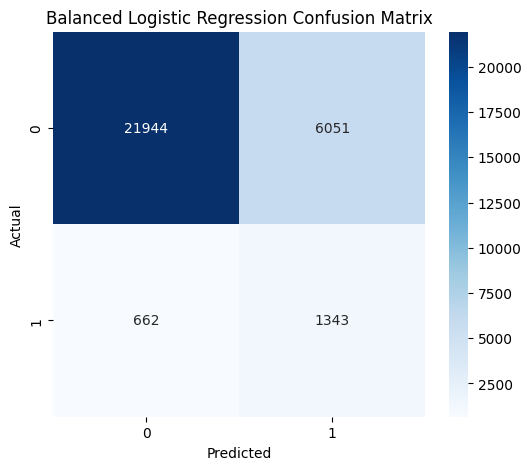

<Figure size 640x480 with 0 Axes>

In [50]:
cm = confusion_matrix(y_test, balanced_y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Balanced Logistic Regression Confusion Matrix")

plt.show()
plt.savefig("../images/correlation_heatmap.png")

Final Conclusion

The objective of this project was to predict customer credit default using historical financial data.

Several machine learning models were evaluated, including Logistic Regression, Balanced Logistic Regression, Decision Tree, Random Forest, and Balanced Random Forest.

Balanced Logistic Regression achieved the highest Recall (67%), identifying the largest number of actual defaulters. Since the cost of missing a defaulter is significantly higher than falsely flagging a safe borrower, this model was selected as the final recommended solution for credit risk assessment.

Although Balanced Random Forest achieved the highest F1-score and ROC-AUC, its Recall remained substantially lower than Balanced Logistic Regression. Therefore, the final model selection was based not only on predictive performance but also on alignment with business objectives.

This project demonstrates the importance of handling class imbalance, preventing data leakage, evaluating models using multiple metrics, and selecting models based on real-world business requirements rather than accuracy alone.